# Choosing k for the `cluster` labeling strategy

Generic and species-agnostic. Supports both a single input file and a
merged, multi-source case (set exactly one of `INPUT_TABLE` /
`MERGE_MANIFEST` below) -- so real multi-condition k-selection no longer
needs a hand-written throwaway script, it uses the same manifest format
`scripts/run_pipeline.py --merge-manifest` does.

This notebook is a PRE-labeling step: it exists to help pick a
defensible `n_clusters` before calling `labelers.cluster()` for real,
either directly or via the CLI. It never writes anything to disk.

Mirrors the workflow taught in the lab's own hierarchical-clustering
material (2023-DG-DataProcessing-11): inspect the raw distribution, run
an elbow curve and silhouette-score curve across a range of k, pick a
candidate, check that candidate's per-sample silhouette coefficients,
look at the dendrogram, and (added here) a real clustermap showing what
the chosen clusters actually look like against the data. Choosing k is
a human judgment call informed by these diagnostics, not something this
notebook decides automatically.

In [1]:
# ---------------------------------------------------------------------------
# Configuration -- the only cell that needs editing for a different dataset.
# Everything below is generic.
# ---------------------------------------------------------------------------

# Set EXACTLY ONE of these two, leave the other as None.

INPUT_TABLE = "/mnt/f/RA/Downstream/Project1_polysomelongread_PR/CR_3D.PR.gene_data.tsv.gz"

MERGE_MANIFEST = None  # e.g. "merge_pr_gene_notebook.txt"

ID_COL = "gene_id"
STRIP_ID_SUFFIX = r"\.v\d+\.\d+$"
EXCLUDE_IDS = ["gene:Standard-R-luc"]

METRIC_COLS = ["PR_gene"]

MAX_K_ELBOW = 15
K_RANGE_SILHOUETTE = range(2, 16)

DROP_UNINFORMATIVE_THRESH = 0

In [2]:
import re
import gzip
import sys, os

_cwd = os.getcwd()
while not os.path.isdir(os.path.join(_cwd, "labelers")) and os.path.dirname(_cwd) != _cwd:
    _cwd = os.path.dirname(_cwd)
sys.path.insert(0, _cwd)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.spatial.distance import pdist
from scipy import stats as scipy_stats

from labelers.labelers import elbow_curve, silhouette_scores, sample_silhouette, cluster
from filters.population import drop_uninformative_for_clustering
from dataprep.merge_tables import merge_gene_tables
from scripts.run_pipeline import read_merge_manifest

assert (INPUT_TABLE is None) != (MERGE_MANIFEST is None), (
    "Set exactly one of INPUT_TABLE or MERGE_MANIFEST above, not both, not neither."
)

if MERGE_MANIFEST:
    sources = read_merge_manifest(MERGE_MANIFEST)
    df = merge_gene_tables(sources, id_col=ID_COL, how="inner")
    print(f"Loaded {len(df)} genes (merged from {MERGE_MANIFEST}, "
          f"{len(sources)} sources, inner join)")
else:
    sources = None
    opener = gzip.open if INPUT_TABLE.endswith(".gz") else open
    with opener(INPUT_TABLE, "rt") as f:
        df = pd.read_csv(f, sep="\t", comment="#")
    print(f"Loaded {len(df)} genes from {INPUT_TABLE}")

if STRIP_ID_SUFFIX:
    df[ID_COL] = df[ID_COL].apply(lambda g: re.sub(STRIP_ID_SUFFIX, "", g))
if EXCLUDE_IDS:
    df = df[~df[ID_COL].isin(EXCLUDE_IDS)]
df = df.dropna(subset=METRIC_COLS)

print(f"After ID normalization / exclusion / dropna: {len(df)} genes")
print(f"Clustering on: {METRIC_COLS}")
df[METRIC_COLS].describe()

Loaded 3594 genes from /mnt/f/RA/Downstream/Project1_polysomelongread_PR/CR_3D.PR.gene_data.tsv.gz
After ID normalization / exclusion / dropna: 3593 genes
Clustering on: ['PR_gene']


,PR_gene
count,3593.000000
mean,0.857627
std,0.672277
min,0.000000
25%,0.555870
50%,0.833805
75%,1.042257
max,7.504249


## Gene overlap across merge sources

Only runs if `MERGE_MANIFEST` is set. Shows how much the inner join
actually removed, and from which side, BEFORE the merge collapses
everything into one number -- `merge_gene_tables()`'s default inner join
means only genes present in EVERY source survive into the population
used below, matching the real precedent's own stated rule for
multi-dataset analysis. Venn diagrams only render cleanly for 2 or 3
sources; more than that falls back to pairwise overlap counts instead.

In [3]:
if sources:
    from matplotlib_venn import venn2, venn3

    # Re-read each source's raw gene IDs directly (before the merge collapses
    # them), applying the same ID normalization used above, so the sets shown
    # here are directly comparable to df's actual population.
    source_gene_sets = {}
    for path, value_col, name in sources:
        s_opener = gzip.open if str(path).endswith(".gz") else open
        with s_opener(path, "rt") as f:
            sdf = pd.read_csv(f, sep="\t", comment="#")
        ids = set(sdf[ID_COL].astype(str))
        if STRIP_ID_SUFFIX:
            ids = {re.sub(STRIP_ID_SUFFIX, "", g) for g in ids}
        source_gene_sets[name] = ids

    print("Gene counts per source (before merging):")
    for name, ids in source_gene_sets.items():
        print(f"  {name}: {len(ids)} genes")
    print()

    names = list(source_gene_sets.keys())
    n_sources = len(names)

    if n_sources == 2:
        fig, ax = plt.subplots(figsize=(6, 6))
        venn2([source_gene_sets[names[0]], source_gene_sets[names[1]]],
              set_labels=(names[0], names[1]), ax=ax)
        ax.set_title("Gene ID overlap across merge sources")
        plt.show()
        overlap = source_gene_sets[names[0]] & source_gene_sets[names[1]]
        print(f"Overlap (this is the inner-join population size below): {len(overlap)} genes")
    elif n_sources == 3:
        fig, ax = plt.subplots(figsize=(6, 6))
        venn3([source_gene_sets[names[0]], source_gene_sets[names[1]], source_gene_sets[names[2]]],
              set_labels=(names[0], names[1], names[2]), ax=ax)
        ax.set_title("Gene ID overlap across merge sources")
        plt.show()
        overlap = source_gene_sets[names[0]] & source_gene_sets[names[1]] & source_gene_sets[names[2]]
        print(f"Overlap of all {n_sources} (this is the inner-join population size below): {len(overlap)} genes")
    else:
        print(f"{n_sources} sources -- Venn diagrams only render cleanly for 2 or 3 sets, "
              f"skipping the diagram. Pairwise overlap counts instead:")
        for i in range(len(names)):
            for j in range(i + 1, len(names)):
                pair_overlap = source_gene_sets[names[i]] & source_gene_sets[names[j]]
                print(f"  {names[i]} & {names[j]}: {len(pair_overlap)}")
        full_overlap = set.intersection(*source_gene_sets.values())
        print(f"Overlap of all {n_sources} (this is the inner-join population size below): {len(full_overlap)} genes")
else:
    print("MERGE_MANIFEST not set -- single-file input, no source overlap to show.")

MERGE_MANIFEST not set -- single-file input, no source overlap to show.


## Uninformative-row preview

A PREVIEW only -- `df` below is not filtered yet. Genes tied at exactly
the same floor value across every clustering column collapse to
identical points after the Yeo-Johnson + Z-score transform, and can
mechanically produce a spuriously "perfect" cluster (a real,
confirmed artifact, see `docs/examples/chlamydomonas.md`). If this
count is large, watch for a suspiciously perfect mean/min silhouette
in the per-sample silhouette step further down -- that is the signal
to actually apply the filter, not this preview number alone.

This is a fix for a clustering-tool mismatch, not a claim these genes
lack real biology: pair any use of this filter with a companion
`boolean_flag`/`explicit_threshold` GO run on the same population to
test the excluded genes on their own terms, see
`filters/population.py`'s docstring for the full reasoning.

In [4]:
if DROP_UNINFORMATIVE_THRESH is not None:
    n_before = len(df)
    would_keep = drop_uninformative_for_clustering(df, METRIC_COLS, thresh=DROP_UNINFORMATIVE_THRESH)
    n_dropped = n_before - len(would_keep)
    print(f"Genes with ALL of {METRIC_COLS} <= {DROP_UNINFORMATIVE_THRESH}: "
          f"{n_dropped} ({n_dropped / n_before:.1%} of {n_before})")
else:
    print("DROP_UNINFORMATIVE_THRESH is None, skipping the uninformative-row preview.")

Genes with ALL of ['PR_gene'] <= 0: 470 (13.1% of 3593)


## Apply the uninformative-row filter (optional)

Off by default. Set `APPLY_DROP_UNINFORMATIVE = True` below only after
reviewing the preview above and, ideally, seeing a suspicious artifact
in the per-sample silhouette step further down -- don't apply this
preemptively just because the preview count is nonzero.

In [5]:
APPLY_DROP_UNINFORMATIVE = False

if APPLY_DROP_UNINFORMATIVE:
    n_before = len(df)
    df = drop_uninformative_for_clustering(df, METRIC_COLS, thresh=DROP_UNINFORMATIVE_THRESH)
    print(f"Applied: {n_before} -> {len(df)} genes")
else:
    print("Not applied -- diagnostics below use the full population.")

Not applied -- diagnostics below use the full population.


## Raw distribution

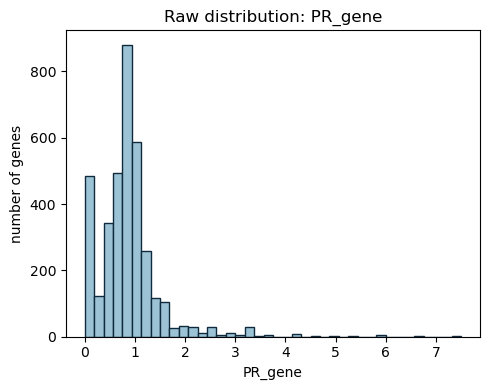

In [6]:
fig, axes = plt.subplots(1, len(METRIC_COLS), figsize=(5 * len(METRIC_COLS), 4), squeeze=False)
for ax, col in zip(axes[0], METRIC_COLS):
    ax.hist(df[col], bins=40, color="#9CC3D5", edgecolor="#0F2A3D")
    ax.set_xlabel(col)
    ax.set_ylabel("number of genes")
    ax.set_title(f"Raw distribution: {col}")
fig.tight_layout()
plt.show()

## Elbow curve

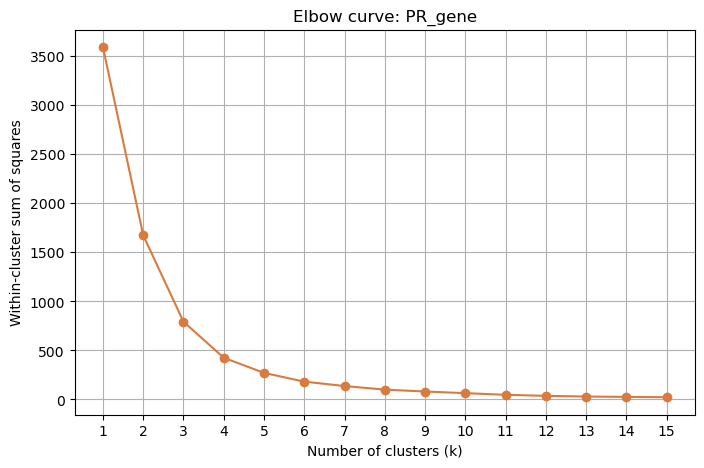

In [7]:
k_list, wss_list = elbow_curve(df, METRIC_COLS, max_k=MAX_K_ELBOW)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(k_list, wss_list, marker="o", color="#D97B3F")
ax.set_xlabel("Number of clusters (k)")
ax.set_ylabel("Within-cluster sum of squares")
ax.set_title(f"Elbow curve: {', '.join(METRIC_COLS)}")
ax.set_xticks(k_list)
ax.grid(True)
plt.show()

## Silhouette score across k

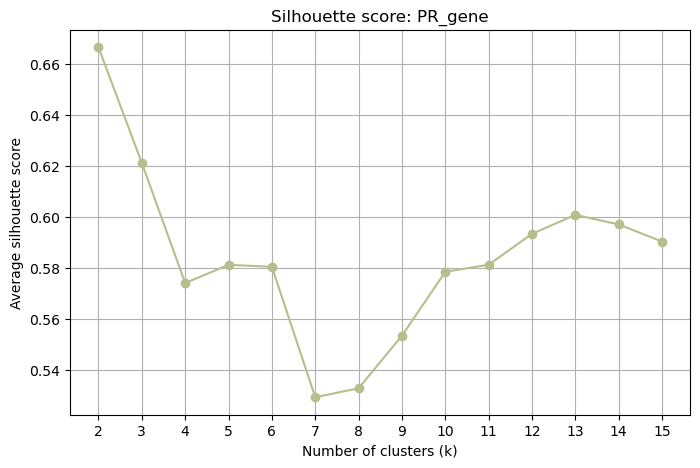

Top 5 candidate k by silhouette score:


,k,silhouette_score
0,2,0.666705
1,3,0.621256
11,13,0.600893
12,14,0.597121
10,12,0.593431


In [8]:
k_list_s, score_list = silhouette_scores(df, METRIC_COLS, k_range=K_RANGE_SILHOUETTE)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(k_list_s, score_list, marker="o", color="#B7BE8D")
ax.set_xlabel("Number of clusters (k)")
ax.set_ylabel("Average silhouette score")
ax.set_title(f"Silhouette score: {', '.join(METRIC_COLS)}")
ax.set_xticks(k_list_s)
ax.grid(True)
plt.show()

score_table = pd.DataFrame({"k": k_list_s, "silhouette_score": score_list})
score_table = score_table.sort_values("silhouette_score", ascending=False)
print("Top 5 candidate k by silhouette score:")
display(score_table.head(5))

## Candidate k

In [9]:
CANDIDATE_K = 2  # <-- set based on the elbow curve and silhouette score above

## Per-sample silhouette at the candidate k

**A cluster with a mean/min silhouette suspiciously at or near exactly
1.0 is the specific signal to check the uninformative-row preview
above** -- a real, confirmed artifact pattern, not hypothetical.

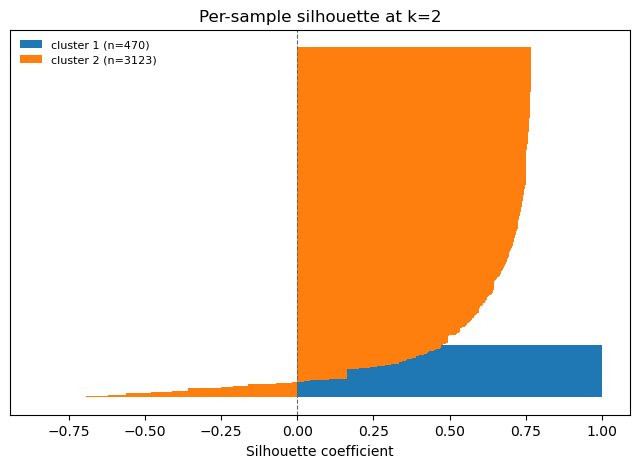

Per-cluster summary:


,count,mean,min
cluster,,,
1,470,1.000000,1.000000
2,3123,0.616545,-0.850298


In [10]:
sil_df = sample_silhouette(df, METRIC_COLS, n_clusters=CANDIDATE_K)

fig, ax = plt.subplots(figsize=(8, 5))
for cluster_id in sorted(sil_df["cluster"].unique()):
    vals = sil_df.loc[sil_df["cluster"] == cluster_id, "silhouette"].sort_values()
    ax.barh(range(len(vals)), vals, left=0, height=1.0,
            label=f"cluster {cluster_id} (n={len(vals)})")
ax.axvline(0, color="0.4", linestyle="--", linewidth=0.8)
ax.set_xlabel("Silhouette coefficient")
ax.set_yticks([])
ax.set_title(f"Per-sample silhouette at k={CANDIDATE_K}")
ax.legend(frameon=False, fontsize=8)
plt.show()

print("Per-cluster summary:")
summary = sil_df.groupby("cluster")["silhouette"].agg(["count", "mean", "min"])
display(summary)

suspicious = summary[(summary["mean"] >= 0.999) & (summary["min"] >= 0.999)]
if len(suspicious):
    print(f"\nWARNING: cluster(s) {list(suspicious.index)} have mean AND min silhouette "
          f"essentially exactly 1.0 -- this is the tied-value artifact pattern, not real "
          f"structure. Check the uninformative-row preview above before trusting this k.")

## Dendrogram

Colored to match `CANDIDATE_K` specifically.

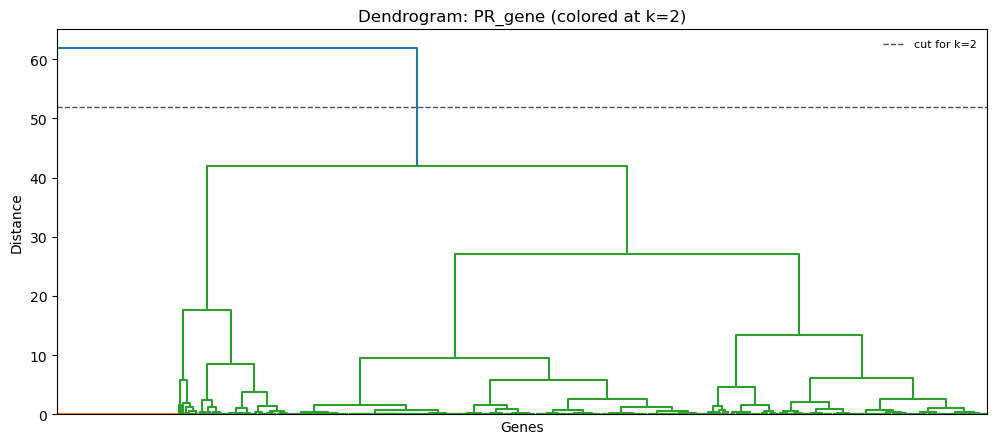

In [11]:
data = df[METRIC_COLS].apply(lambda c: scipy_stats.yeojohnson(c)[0])
z = (data - data.mean()) / data.std()
link = linkage(pdist(z.values, metric="euclidean"), method="ward")

merge_dists = sorted(link[:, 2], reverse=True)
if CANDIDATE_K > 1:
    color_threshold = (merge_dists[CANDIDATE_K - 2] + merge_dists[CANDIDATE_K - 1]) / 2
else:
    color_threshold = merge_dists[0] + 1

fig, ax = plt.subplots(figsize=(12, 5))
dendrogram(link, ax=ax, no_labels=True, color_threshold=color_threshold)
ax.axhline(color_threshold, color="0.3", linestyle="--", linewidth=1,
           label=f"cut for k={CANDIDATE_K}")
ax.set_xlabel("Genes")
ax.set_ylabel("Distance")
ax.set_title(f"Dendrogram: {', '.join(METRIC_COLS)} (colored at k={CANDIDATE_K})")
ax.legend(frameon=False, fontsize=8)
plt.show()

## Clustermap

Column clustering only when 3+ columns are being clustered.

Column clustering: disabled (1 column(s) -- need >= 3 for column clustering to be meaningful)


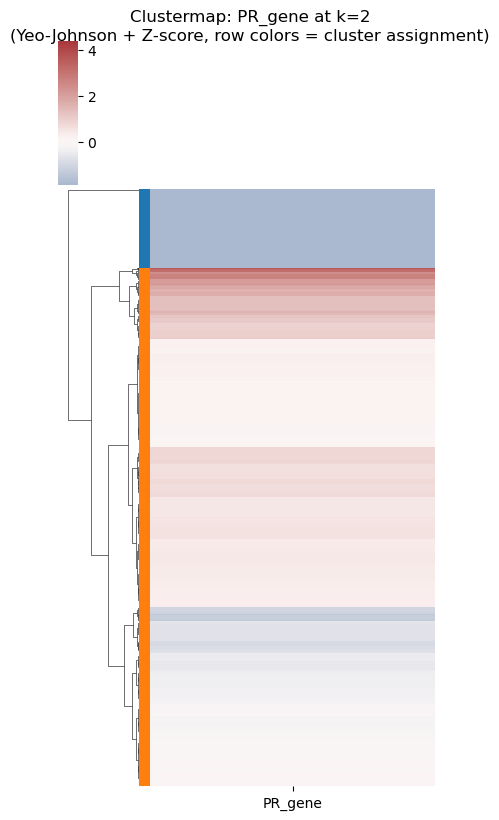

In [12]:
labeled = cluster(df, METRIC_COLS, n_clusters=CANDIDATE_K)
cluster_ids = labeled["class"]

palette = sns.color_palette("tab10", n_colors=cluster_ids.nunique())
lut = dict(zip(sorted(cluster_ids.unique(), key=int), palette))
row_colors = cluster_ids.map(lut)

cluster_col_axis = len(METRIC_COLS) >= 3
print(f"Column clustering: {'enabled' if cluster_col_axis else 'disabled'} "
      f"({len(METRIC_COLS)} column(s) -- need >= 3 for column clustering to be meaningful)")

g = sns.clustermap(
    z,
    method="ward", metric="euclidean",
    row_cluster=True, col_cluster=cluster_col_axis,
    row_colors=row_colors.values,
    cmap="vlag", center=0,
    yticklabels=False,
    figsize=(max(4, len(METRIC_COLS) * 1.8), 8),
)
g.fig.suptitle(f"Clustermap: {', '.join(METRIC_COLS)} at k={CANDIDATE_K}\n"
               f"(Yeo-Johnson + Z-score, row colors = cluster assignment)", y=1.02)
plt.show()

## Next step

Single-file case:

```bash
python scripts/run_pipeline.py \
    --input-table <same path as INPUT_TABLE above> \
    --godb <path to .godb> \
    --metric-col <same as METRIC_COLS> \
    --label-strategy cluster --n-clusters <CANDIDATE_K> \
    --output-dir results/GO \
    --dataset-name <run name>
```

Merged case:

```bash
python scripts/run_pipeline.py \
    --merge-manifest <same path as MERGE_MANIFEST above> \
    --godb <path to .godb> \
    --metric-col <same section names as METRIC_COLS> \
    --label-strategy cluster --n-clusters <CANDIDATE_K> \
    --output-dir results/GO \
    --dataset-name <run name>
```

If `APPLY_DROP_UNINFORMATIVE` was used above, add `--drop-uninformative`
(and `--drop-uninformative-thresh` if not 0), AND run a companion
`--label-strategy boolean_flag` or `explicit_threshold` pass on the
excluded genes separately.

This notebook never writes anything to disk.